In [1]:
import pandas as pd
df = pd.read_parquet("large_dataset.parquet")
df_work = df.copy()
df_work.head()

,date,text,decade,category,year
0,2023.0,Ahmed Abdel Mougod Soliman (born 19 December 1...,2020.0,None,NaN
1,1937.0,asked the Chancellor of the Exchequer whether ...,1930.0,None,NaN
2,2022.0,HAL is a multi-disciplinary open access archiv...,2020.0,None,NaN
3,2011.0,CALIFORNIA AIR RESOURCES BOARD \n\nSIP COMPLET...,2010.0,None,NaN
4,2017.0,Which assumptions about the variance need to h...,2010.0,None,NaN


<Axes: xlabel='text_length', ylabel='Count'>

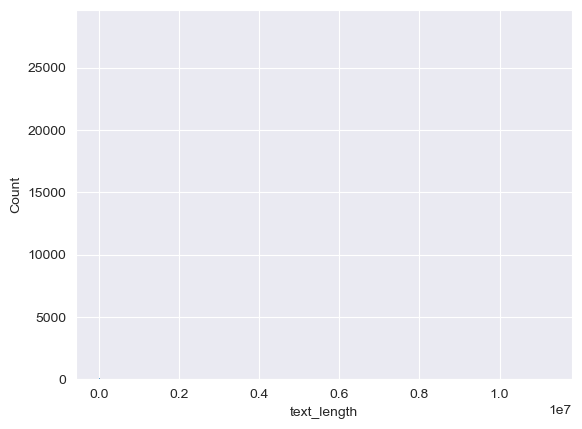

In [2]:
import seaborn as sns
df_work["text_length"] = df_work["text"].str.len()
sns.histplot(data=df_work, x="text_length")

5000

,date,text,decade,category,year,text_length
0,1967.0,"Yes, but I do not think that with these items ...",1960.0,None,NaN,305
1,NaN,LIBRARY OF CONGRESS \n\n\n\n\n014 314 837 3 % ...,1910.0,book,1913.0,23028
2,NaN,"John M. Kane, of Pt. Huron, was in the village...",1880.0,None,1887.0,5306
3,NaN,At the afternoon session OF the Epi-cOpal cone...,1890.0,None,1892.0,6907
4,NaN,CHAPTER I.\n\nPage\n\nGEOGRAPHICAL DESCRIPTION...,1850.0,None,1854.0,277213
...,...,...,...,...,...,...
4995,NaN,whose day ends at sunset and begins before coc...,1880.0,None,1880.0,8062
4996,NaN,than one hundred and fifty thousand gentlemen ...,1790.0,Book,1792.0,2878
4997,1997.0,"Becker, J.\n— Karl Becker was riding in the bo...",1990.0,None,NaN,15212
4998,NaN,ne senator from South Carolina his cooquV sena...,1840.0,None,1847.0,8987


In [20]:
import re
STOPWORDS = {'the', 'and', 'is', 'in', 'to', 'of', 'a', 'that', 'it', 'with', 'for', 'as', 'was', 'on', 'are', 'by', 'this', 'be', 'or', 'from', 'at', 'an', 'have', 'which', 'has'}

def is_actual_prose(text):
    if not isinstance(text, str):
        return False
    text = text.strip()
    if len(text) < 15:
        return False
    noise_chars = len(re.findall(r'[\d_\%\×\=\+\<\>\|\-\/]', text))
    if (noise_chars / len(text)) > 0.15:
        return False
    words = set(re.findall(r'\b[a-zA-Z]+\b', text.lower()))
    stopword_count = len(words.intersection(STOPWORDS))
    if stopword_count < 2:
        return False
    return True

df_work['text'] = df_work['text'].str.replace('\xa0', ' ')
df_work['text'] = df_work['text'].str.split(r'\n+', regex=True)
df_work = df_work.explode('text')
df_work = df_work[df_work['text'].apply(is_actual_prose)].reset_index(drop=True)

In [21]:
df = pd.read_parquet("large_dataset.parquet")
df = pd.concat([df, df_work], ignore_index=True)
df.to_parquet("large_dataset.parquet")
df.head()

,date,text,decade,category,year,text_length
0,NaN,PRIVATELY PRINTED BY THE,1920.0,book,1920.0,855189
1,NaN,Firm in Faith and in War,1920.0,book,1920.0,855189
2,NaN,Irish History with Special Reference to the Ma...,1920.0,book,1920.0,855189
3,NaN,Description of the Old Home and Surrounding Co...,1920.0,book,1920.0,855189
4,NaN,Letters of Sympathy from Old North Brookfield ...,1920.0,book,1920.0,855189
...,...,...,...,...,...,...
826276,2015.0,Since you have some responses below that seem ...,2010.0,None,NaN,1838
826277,2015.0,"Or, without additional package, use a \raisebox:",2010.0,None,NaN,1838
826278,2015.0,"By the way, the optional argument for tabular ...",2010.0,None,NaN,1838
826279,NaN,Adhesions in the Breast The Gangrene or Mortif...,1770.0,Book,1771.0,2868
